# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/processed_full_data'+runs+'runs'+'-'+comment+'.pkl'
# d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
# '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl'
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/list_processed_full_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_I,I_0,S_0,N_0,d_S,K_H,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,harm_pI,harm_pS,max_eM_fold,frac_cM,log_T_pEcyteM,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,scaled_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity,peff_protection
0,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,1.0,1.5,2.25,-1.5,1.0,1.5,0.75,-0.0,0.0,0.0,-27.0,1.5,-1.0,-1.5,-3.00,3.144705e+04,1.314438e+07,0.0,0.271084,0.0,3.228,2.364,0.516,59.484,0.826514,0.008190,3.126249,0.004392,3.349148,1.386375,1.383231e+00,1.314438,0.068793
1,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,1.0,1.5,2.25,-1.5,1.0,1.5,0.75,-0.0,0.0,0.0,-27.0,1.5,-1.0,-1.5,-2.25,8.082690e+04,1.139168e+07,0.0,0.307692,0.0,4.344,3.276,0.384,41.808,1.324014,0.018277,3.105921,0.004408,3.349148,1.386375,1.378293e+00,1.139168,0.239125
2,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,1.0,1.5,2.25,-1.5,1.0,1.5,0.75,-0.0,0.0,0.0,-27.0,1.5,-1.0,-1.5,-1.50,1.382658e+07,8.218694e+03,0.0,0.406475,0.0,0.000,9.012,0.492,3.540,6.523833,1.791494,0.055801,0.015078,3.349148,1.386375,3.717447e-03,0.000822,0.002896
3,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,1.0,1.5,2.25,-1.5,1.0,1.5,0.75,-0.0,0.0,0.0,-27.0,1.5,-1.0,-1.5,-0.75,1.383736e+07,4.480088e+03,0.0,0.400000,0.0,0.000,8.928,0.480,3.060,6.525190,1.792599,0.023925,0.015055,3.349148,1.386375,2.639623e-03,0.000448,0.002192
4,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,1.0,1.5,2.25,-1.5,1.0,1.5,0.75,-0.0,0.0,0.0,-27.0,1.5,-1.0,-1.5,0.00,1.385253e+07,1.723337e+03,0.0,0.288321,0.0,0.000,8.796,0.360,2.724,6.526043,1.793294,0.007762,0.015041,3.349148,1.386375,1.122813e-03,0.000172,0.000950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117591745,1.500000e-07,1.50,10000000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.5,2.0,3.00,0.0,0.5,2.0,1.50,0.0,0.0,0.0,-27.0,-0.0,-0.5,-2.0,0.00,1.036000e+03,1.037286e+07,0.0,0.181556,0.0,0.024,0.000,0.516,16.344,0.000100,0.003307,3.159699,0.007636,0.532046,0.000104,-2.273737e-20,1.037286,-1.037286
117591746,1.500000e-07,1.50,10000000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.5,2.0,3.00,0.0,0.5,2.0,1.50,0.0,0.0,0.0,-27.0,-0.0,-0.5,-2.0,0.75,1.036000e+03,6.442198e+06,0.0,0.131367,0.0,0.024,0.000,0.372,28.224,0.000100,0.003307,2.074196,0.390468,0.532046,0.000104,-2.273737e-20,0.644220,-0.644220
117591747,1.500000e-07,1.50,10000000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.5,2.0,3.00,0.0,0.5,2.0,1.50,0.0,0.0,0.0,-27.0,-0.0,-0.5,-2.0,1.50,1.036000e+03,3.174502e+03,0.0,0.188034,0.0,0.024,0.000,0.360,3.180,0.000100,0.003307,0.003677,0.999702,0.532046,0.000104,0.000000e+00,0.000317,-0.000317
117591748,1.500000e-07,1.50,10000000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.5,2.0,3.00,0.0,0.5,2.0,1.50,0.0,0.0,0.0,-27.0,-0.0,-0.5,-2.0,2.25,1.036000e+03,2.929955e+03,0.0,0.176471,0.0,0.024,0.000,0.384,3.312,0.000100,0.003307,0.003795,0.999715,0.532046,0.000104,-4.547474e-20,0.000293,-0.000293


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)
num_psis = len(Na_reg)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:-12] + param_names[-12:-8] + param_names[-4:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)
tol = 1e-2

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,0.532046,0.000100,0.003307,3.328404
1,0.544286,0.002457,0.159179,3.316607
2,0.556817,0.009260,0.474249,3.317799
3,0.562162,0.000164,0.003307,3.329158
4,0.569737,0.020708,0.815945,3.328026
...,...,...,...,...
220,2.758122,6.034064,1.793700,3.527937
221,2.843699,5.871880,2.147638,3.316828
222,2.964652,6.093303,2.124792,3.291041
223,3.120998,6.309190,2.026831,3.394334


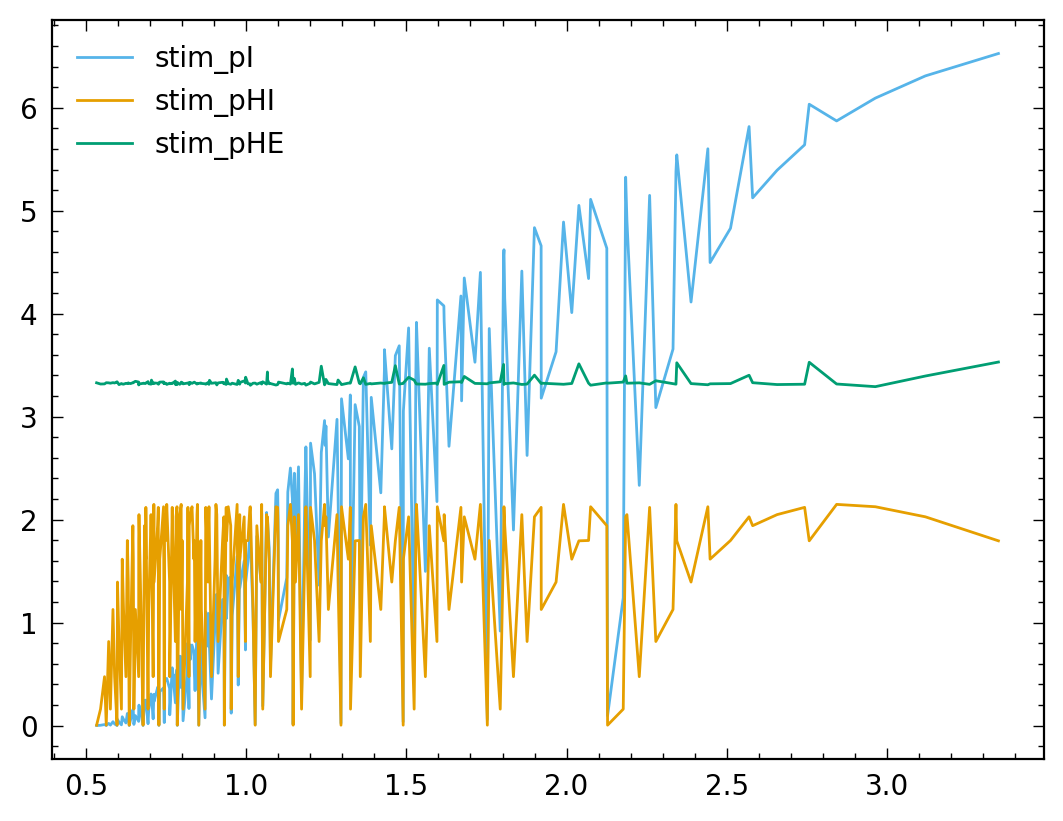

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

In [6]:
# # Explore noise in the data
# fig, axs = plt.subplots(1, len(perf_vars), 
#                               figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)


# data_mean = clustered_mean_df.groupby(reg + vir_vars, as_index = False).std()
        
# for i, var in enumerate(perf_vars):
#     im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
#                         (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
#                       marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
#                         edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

#     if module_index + j == 0: 
#         axs[i].minorticks_off()
#         axs[i].yaxis.set_tick_params(labelbottom=True)
#         axs[i].xaxis.set_tick_params(labelbottom=True)
#         axs[i].tick_params(axis='both', which='major', labelsize=8)
#         axs[i].set_box_aspect(1)
#         axs[i].locator_params(axis='y', nbins=4)
#         axs[i].locator_params(axis='x', nbins=4)
#         axs[i].set_ylabel("St. dev.\n"+perf_labels[i], fontsize = 12)
#         axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

# axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
# fig.subplots_adjust(wspace=.4, hspace=.35)
# #plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 9
fevals: 28
fevals: 8
fevals: 29
fevals: 9
fevals: 28
fevals: 8
fevals: 10
fevals: 9
fevals: 28
fevals: 8
fevals: 15


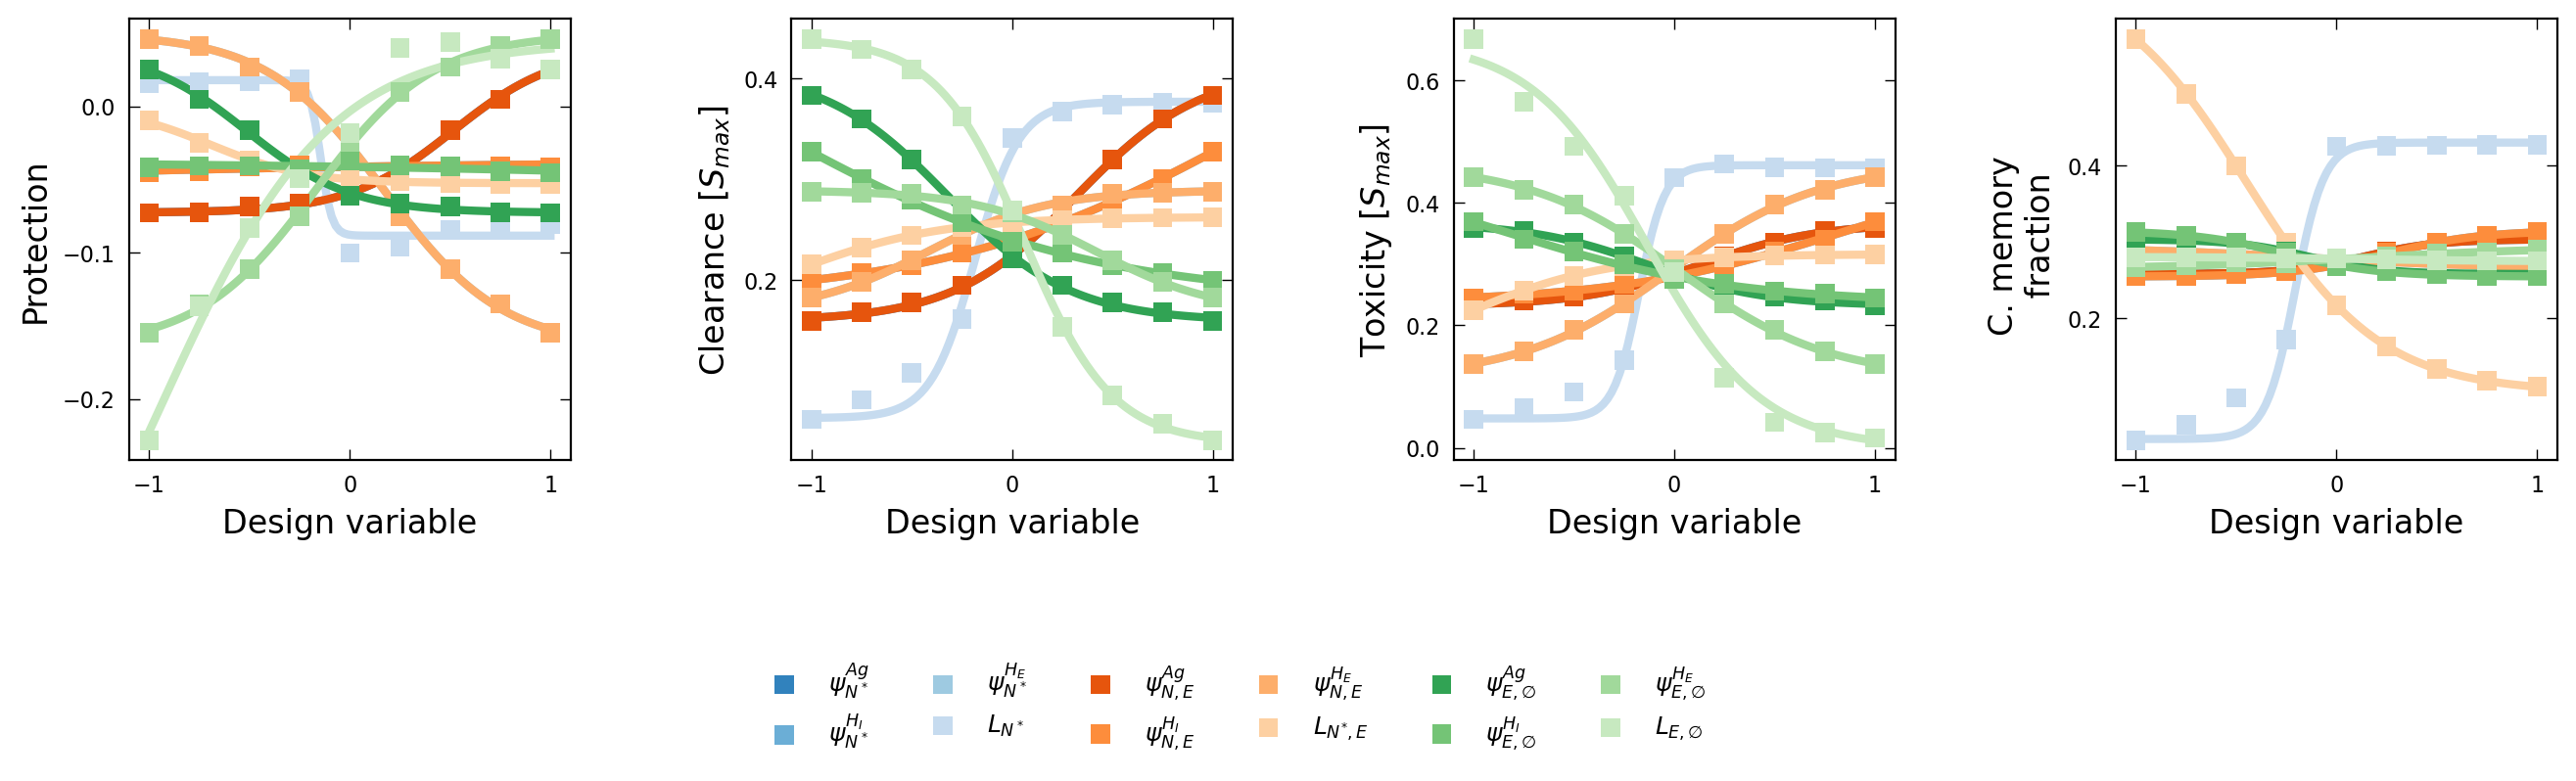

In [7]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2, len(perf_vars)), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, (var, ax) in enumerate(zip(perf_vars, axs.flat)):
            im = ax.scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
                                (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - tol*y_std, np.minimum(2*y_min, 0), -4*L0_max, -4*L0_max], 
                                             [2*y_max if y_max > 0 else y_std*tol, np.maximum(y_min, 0) + y_std*tol, 4*L0_max, 4*L0_max]),
                                   maxfev=10000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            ax.plot(x/np.amax(x), (10**sigmoid_1d(x, *popt) - 1) if i == 4 or i == 5 else sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j],
                        #label = reg_label[module_index*len(reg_choice) + j ],
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                ax.minorticks_off()
                ax.yaxis.set_tick_params(labelbottom=True)
                ax.xaxis.set_tick_params(labelbottom=True)
                ax.tick_params(axis='both', which='major', labelsize=8)
                ax.set_box_aspect(1)
                ax.locator_params(axis='y', nbins=4)
                ax.locator_params(axis='x', nbins=4)
                ax.set_ylabel(perf_labels[i], fontsize = 12)
                ax.set_xlabel(r'Design variable', fontsize = 12)

axs[1].legend(loc='lower center', bbox_to_anchor=(1.0, -0.71), fontsize=9, framealpha=0, ncol=len(reg_label) // 2)

#legend(bbox_to_anchor=(1.1, 1), fontsize=12, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.5, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=300, bbox_inches="tight")

In [8]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [10]:
# Regress Performance measures on regulation parameters
num_cpu = 145
variables = reg
tol = 1e-2
fit = "sigmoid_linear"

def model(input, fit = fit):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        
        elif fit == "sigmoid_linear":
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_std*tol, np.minimum(0.0, y_min)] + len(variables)*[-15*L0_max] + num_modules*[-15*L0_max], 
                                     [1.0 if perf == "frac_cM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[15*L0_max] + num_modules*[15*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, 
                                                                                               np.amax(input['scaled_min_pS'].values),
                                                                                               input['harm_pI_noprotection'].values[0],
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values),
                                                                                               ])
            
        elif fit == "sigmoid_nonlinear":
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(modified_sigmoid, input[variables].values, input[perf].values, 
                           p0 = [y_max, y_min] + len(variables)*[0.0] + num_modules*[0.0] + (3*num_modules)*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_std*tol, np.minimum(0.0, y_min)] + len(variables)*[-15*L0_max] + num_modules*[-15*L0_max] + (3*num_modules)*[-15*L0_max], 
                                     [1.0 if perf == "frac_cM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[15*L0_max] + num_modules*[15*L0_max] + (3*num_modules)*[15*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - modified_sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, 
                                                                                               np.amax(input['scaled_min_pS'].values),
                                                                                               input['harm_pI_noprotection'].values[0],
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values),
                                                                                               ])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ([('interact_' + str(j)) for j in np.arange(0, 9)] if fit == "sigmoid_nonlinear" else []) \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + ([('sigma_interact_' + str(j)) for j in np.arange(0, 9)] if fit == "sigmoid_nonlinear" else []) \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), 
                                                                                                                        fit = "sigmoid_linear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ([('interact_' + str(j)) for j in np.arange(0, 9)] if fit == "sigmoid_nonlinear" else []) \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + ([('sigma_interact_' + str(j)) for j in np.arange(0, 9)] if fit == "sigmoid_nonlinear" else []) \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [11]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [12]:
# View result
perf_choice = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None,'display.max_rows', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1,1.391247e+00,2.062935e-03,3.005284,0.218695,0.224279,1.977210,1.842055,-0.009541,0.182246,1.780487,-3.834283,-0.296678,-0.395074,-1.963233,2.041737,6.207890,0.756562,6.216967e-04,4.474409e-04,9.591164e-03,2.620510e-03,2.630721e-03,6.604590e-03,1.493603e-02,6.382346e-03,6.447446e-03,1.980253e-02,1.114469e-02,2.481391e-03,2.588437e-03,5.964747e-03,8.381746e-03,5.704127e-02,4.508465e-03,0.150000,1.000000e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,5.823878e-01,1.384991e+00,0.000000e+00,0.149905,1.0,1.984104e-01,6.256584e-01,0.990263,1.386375,6.526541,1.793700,3.145543,3.349148
5,1.390878e+00,1.827027e-04,2.351968,0.193210,0.219023,1.883983,1.388542,-0.021597,0.175723,1.811803,-3.268047,-0.283792,-0.418279,-1.993718,1.945062,6.370933,0.766931,7.186752e-04,4.889084e-04,7.539263e-03,2.461401e-03,2.487175e-03,6.147304e-03,1.162391e-02,6.292226e-03,6.359278e-03,2.109294e-02,9.662742e-03,2.427540e-03,2.579009e-03,6.076159e-03,7.863305e-03,6.109295e-02,4.484472e-03,0.150000,1.637894e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,5.629689e-01,1.384766e+00,0.000000e+00,0.170364,1.0,2.098944e-01,6.111893e-01,0.986485,1.386375,6.034064,1.793700,3.129423,2.758122
9,1.390265e+00,2.270999e-03,1.898840,0.184291,0.227141,1.827666,0.993206,-0.015499,0.171478,1.822107,-2.810214,-0.286179,-0.483773,-2.005257,1.818132,6.535322,0.619387,8.090835e-04,5.137857e-04,6.316299e-03,2.396675e-03,2.438987e-03,5.849980e-03,9.495315e-03,6.425550e-03,6.506708e-03,2.430773e-02,8.503240e-03,2.396477e-03,2.638285e-03,6.090465e-03,7.381226e-03,7.097811e-02,4.240242e-03,0.150000,2.682696e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,5.370735e-01,1.384303e+00,0.000000e+00,0.141028,1.0,2.167602e-01,5.961597e-01,0.976179,1.386375,5.542180,1.793700,3.155361,2.344404
13,1.389761e+00,5.827153e-03,1.557608,0.194748,0.267731,1.816688,0.708968,-0.028362,0.160361,1.787318,-2.431337,-0.298567,-0.543747,-2.037342,1.683060,6.575079,0.418888,8.875530e-04,5.197749e-04,5.428060e-03,2.408059e-03,2.483761e-03,5.696531e-03,8.388384e-03,6.652484e-03,6.713971e-03,2.758637e-02,7.538812e-03,2.421516e-03,2.755877e-03,6.157890e-03,6.916493e-03,8.110709e-02,3.975126e-03,0.150000,4.393971e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,5.089248e-01,1.383934e+00,0.000000e+00,0.100179,1.0,2.191974e-01,5.827153e-01,0.952352,1.386375,5.051265,1.793700,3.173639,2.038612
17,1.389188e+00,5.707982e-03,1.311345,0.203218,0.341939,1.883579,0.485554,-0.026068,0.200106,1.713971,-2.121607,-0.318168,-0.592859,-2.115821,1.562575,6.477911,0.191865,9.443694e-04,5.037687e-04,4.804631e-03,2.454116e-03,2.610179e-03,5.838961e-03,7.756831e-03,6.802901e-03,6.916357e-03,2.948411e-02,6.717758e-03,2.471162e-03,2.881201e-03,6.372602e-03,6.532632e-03,8.701782e-02,3.733087e-03,0.150000,7.196857e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,4.789839e-01,1.383480e+00,0.000000e+00,0.060251,1.0,2.172652e-01,5.707982e-01,0.907564,1.386375,4.561929,1.793700,3.170268,1.803387
21,1.388119e+00,5.591620e-03,1.137762,0.220389,0.440655,2.037211,0.342175,-0.005915,0.308933,1.691907,-1.872736,-0.340037,-0.661561,-2.260400,1.443096,6.485955,-0.091298,9.614841e-04,4.665275e-04,4.395327e-03,2.527969e-03,2.814111e-03,6.327425e-03,7.391077e-03,6.789304e-03,7.177933e-03,2.975372e-02,6.048640e-03,2.525066e-03,3.044568e-03,6.800683e-03,6.214144e-03,8.804178e-02,3.571162e-03,0.150000,1.178769e+05,1.500000e-07,100000.0,100

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

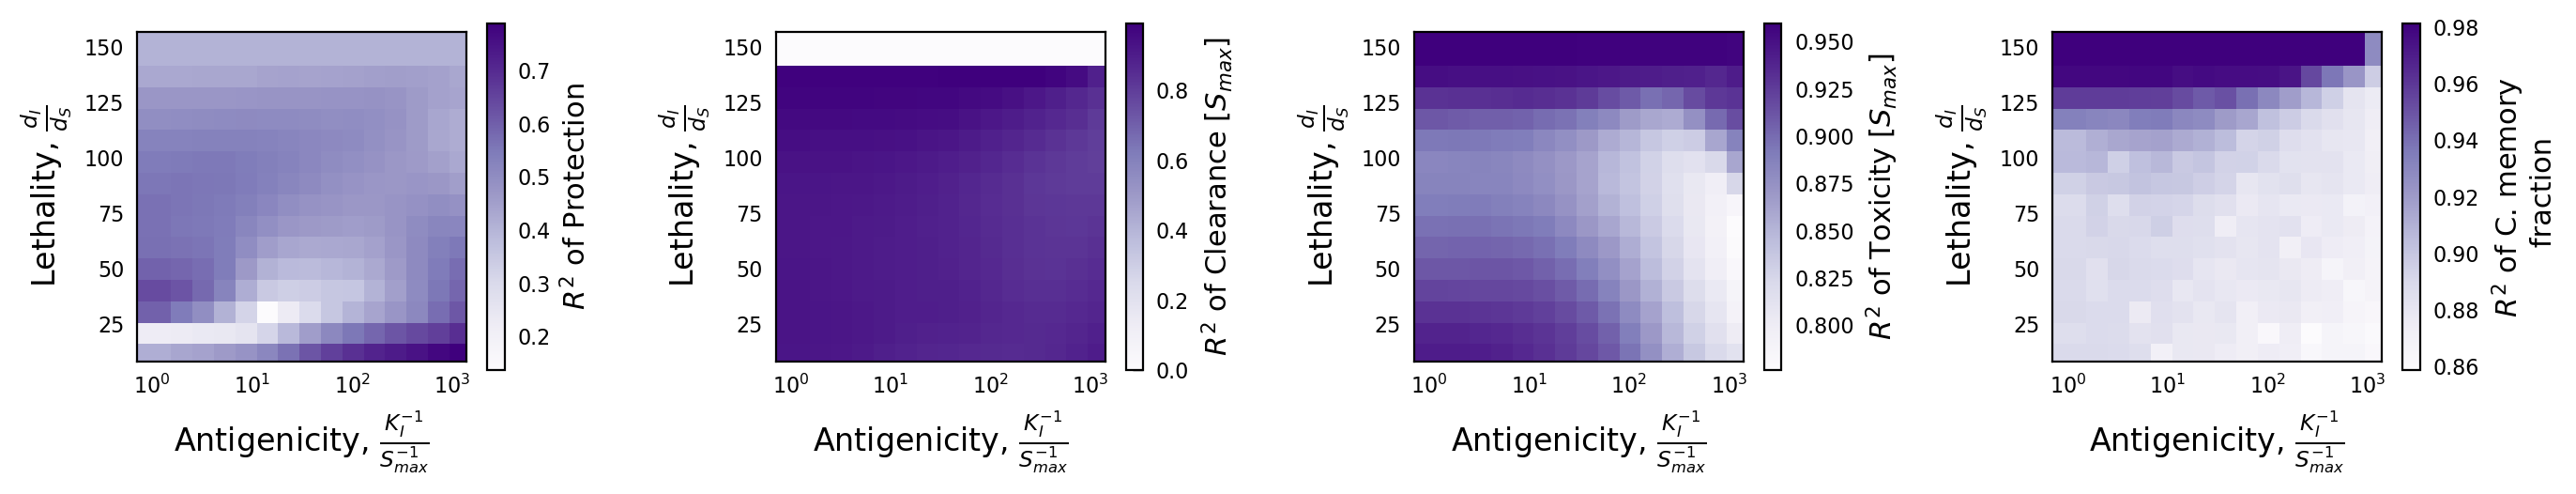

In [13]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2)*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.55, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

In [15]:
# # Examine goodness of fit through R-squared
# size = 3200/np.sqrt(len(infection_scenarios))

# fig, axs = plt.subplots(1, len(perf_vars), 
#                           figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

# x_varname, y_varname = vir_vars[1], vir_vars[4]
# for i, perf in enumerate(perf_vars):
#     data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 > I_min)]
#     model_r_sq = (1 - data.rmse**2/data.y_std**2) #*(data.y_std > tol)
#     z_label = r"$R^2$ of "+perf_labels[i]
    
#     im = axs[i].scatter(data['S_0']/data[x_varname], data[y_varname],
#                       marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
#                       norm = mpl.colors.Normalize())

#     axs[i].semilogx()
#     axs[i].semilogy()
        
#     axs[i].minorticks_off()
#     axs[i].set_box_aspect(1)
#     axs[i].tick_params(axis='both', which='major', labelsize=8)

#     cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
#     cb.set_label(z_label, fontsize = 11)
#     cb.ax.tick_params(labelsize=8)
    
# fig.subplots_adjust(wspace=0.40, hspace=0.25)

# for k, ax in enumerate(axs.flat):
#     ax.set_xlabel("Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", fontsize = 12)
#     ax.set_ylabel("Dosage, "+r"$N_0$", fontsize = 12)

# plt.savefig('_figs/'+comment+'-fits-r-squared-cancers'+'.png', dpi=150, bbox_inches="tight")

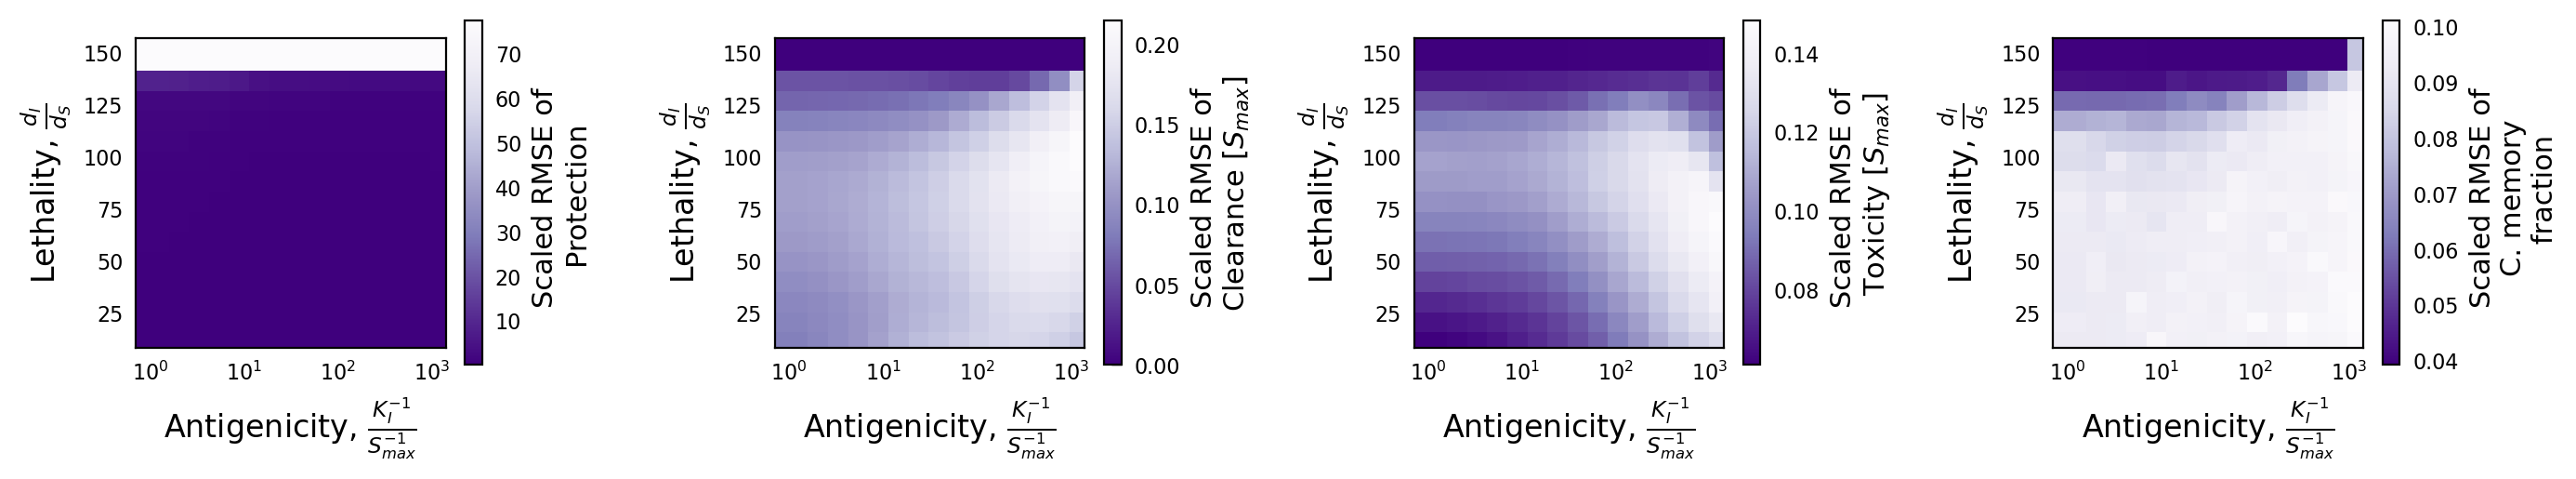

In [16]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_rmse_over_max = (data.rmse/data.y_max)*(data.y_std > tol)
    z_label = "Scaled RMSE of \n"+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.65, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

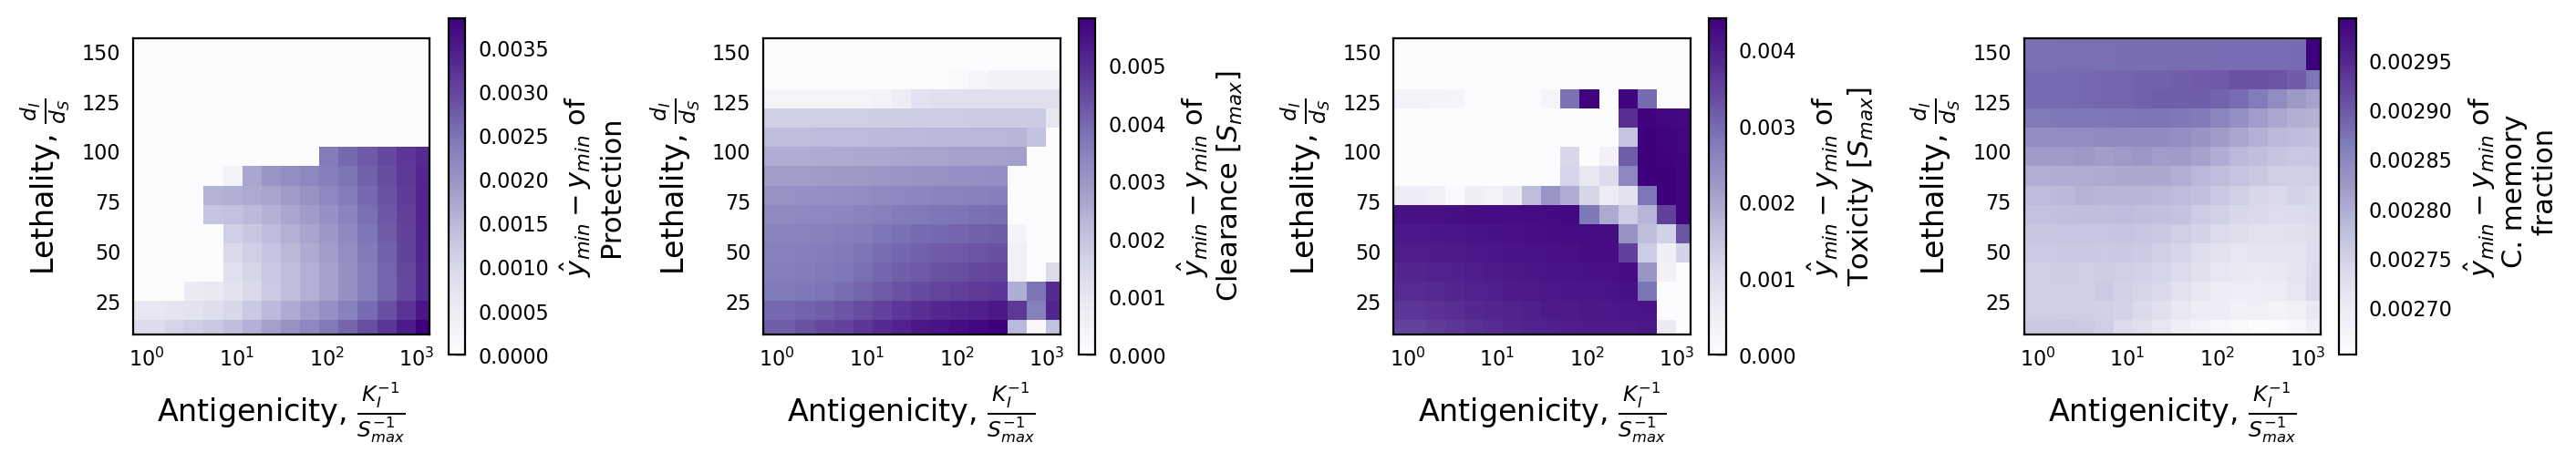

In [17]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{min} - y_{min}$"+ " of\n"+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_min - data.min_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.7, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

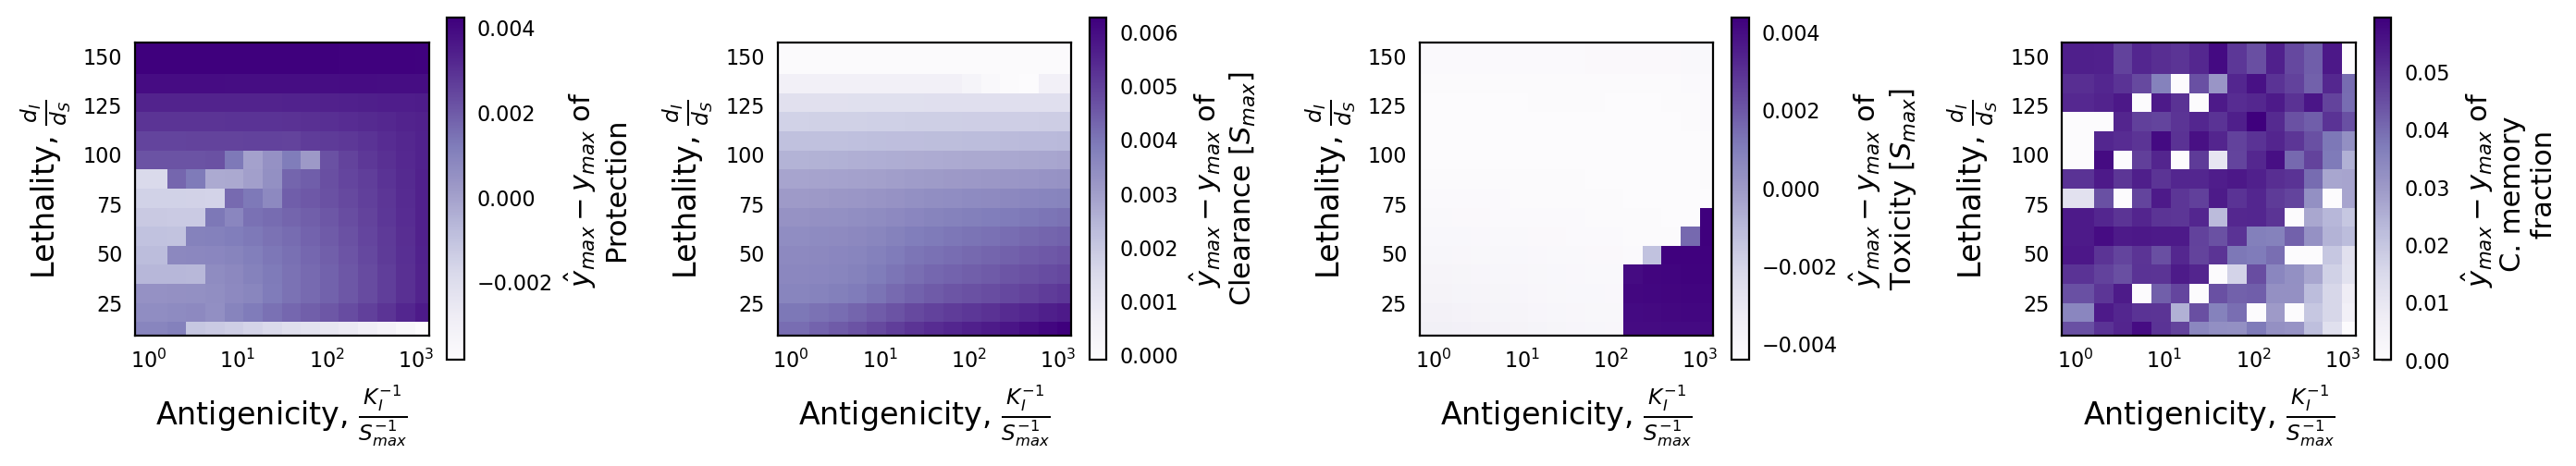

In [18]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of"+"\n"+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_max - data.max_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.75, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

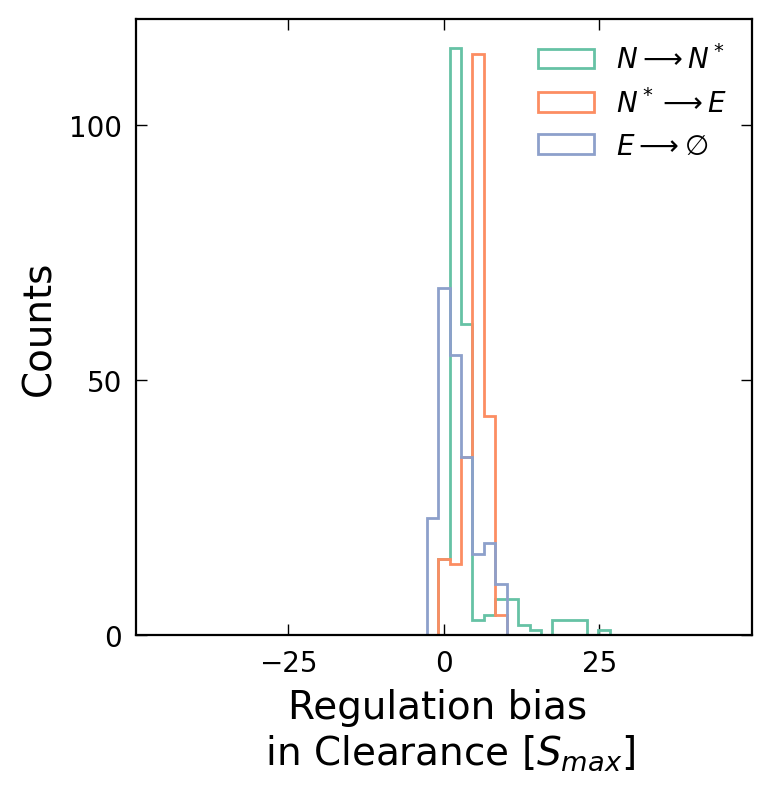

In [19]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

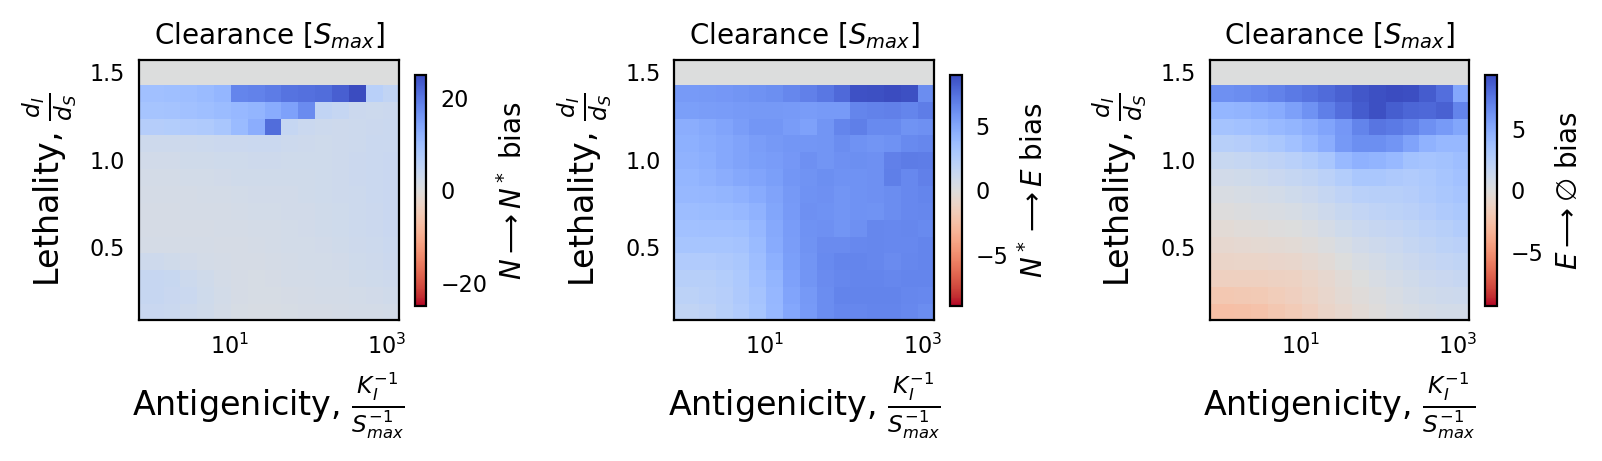

In [20]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1250/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    z = data[z_varname]
    range = np.amax(np.abs(z))
    
    im = axs[i].scatter(S_0/data[x_varname] if x_varname == 'K_I' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_I' else data[y_varname],
                      marker ='s', s = size, c = z, cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.65, hspace=0.5)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

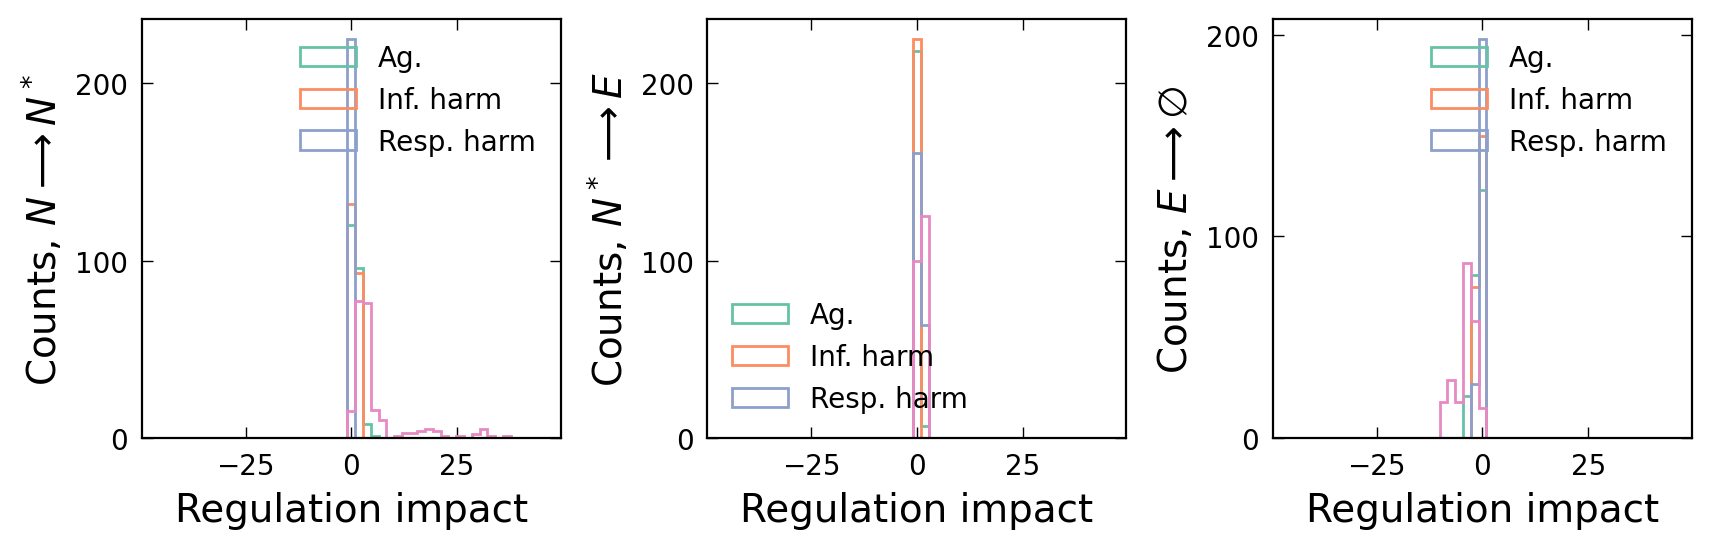

In [21]:
fig, axs = plt.subplots(1,3, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)][r].values
    module = i // num_psis
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    axs[module].hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = signal_classes[i % num_psis], color = cmap_colors[i % num_psis], stacked = True);

    if (i % num_psis) == num_modules -1:
        axs[module].legend(fontsize = 10, ncol = 1)
    
        axs[module].set_xlabel("Regulation impact", fontsize = 14)
        axs[module].set_ylabel("Counts, "+module_labels[i // num_psis], fontsize = 14)
        axs[module].set_box_aspect(1)
        axs[module].minorticks_off()
        axs[module].locator_params(axis='y', nbins=4)
        axs[module].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [ ]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

In [ ]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])